In [ ]:
import math

def k_means_distance(data, k):

    # Checks that all rows have the same number of columns.
    for datapoint in data:
        if len(datapoint) != len(data[0]):
            raise TypeError('All rows must have the same number of columns')
    if k < 1 or k > len(data):
        raise TypeError("K must be more than 0")
    
    # Assigns a number 1 through k to the original points and produces numbered_data
    num = 1
    numbered_data = []
    for datapoint in data:   
        if num == k + 1:
            num = 1
        point = []
        point.append(num)
        for i in datapoint:
            point.append(i)
        numbered_data.append(point)
        num += 1
    
    while True:

        # If this is the same at the end, we have succesfully clustered our data.
        # Doing it this way to make sure it isnt a reference. List comprehension makes it concise.
        previous_assignments = [points[0] for points in numbered_data] 

        # Now organize data into their respective clusters
        clusters = []
        for i in range(1, k+1):
            individual_cluster = []
            for datapoint in numbered_data:
                if datapoint[0] == i:
                    individual_cluster.append(datapoint)
            clusters.append(individual_cluster)

        # Now calculate centers

        # Creates skeleton of 0s
        cluster_centers = []
        for i in range(k):
            cluster_center = []
            for j in range(len(data[0])):
                cluster_center.append(0.0)
            cluster_centers.append(cluster_center)

        # add sums for each cluster to cluster center
        for i in range(k):
            for j in range(len(data[0])):
                for datapoint in clusters[i]:
                    cluster_centers[i][j] += datapoint[j+1]
        
        # divide by number of datapoints to get average distance to cluster center for a given datapoint
        for i in range(k):
            if len(clusters[i]) != 0:
                for j in range(len(data[0])):
                    cluster_centers[i][j] /= len(clusters[i])
            else:
                cluster_centers[i] = data[i % len(data)][:] 
                # An empty cluster is just set to a random data point, which is fine in practice.
                # [:] makes a copy, so it isn't a reference that will mess other stuff up later

        minimized_distances = [] # important for return value. We return the total distance to quantify it for our graph. Simple arthimetically

        # recalculate distances for a given point and reassign the point to the nearest cluster.
        for datapoint in numbered_data:
            distances = []
            for i in range(k):
                distance = 0
                for j in range(len(data[0])):
                    distance += (datapoint[j + 1] - cluster_centers[i][j])**2
                distance = math.sqrt(distance)
                distances.append(distance)
            min_distance = min(distances)
            minimized_distances.append(min_distance) # add to our minimized distance, if not true minimized distance, it will be reset.
            min_idx = distances.index(min_distance)
            datapoint[0] = min_idx + 1 # because indexs are at 0 but cluster numbers aren't
                   

        current_data = [point[0] for point in numbered_data]
        if current_data == previous_assignments: #convergence
            break 
    
    # quantify distance
    total_distance = 0
    for num in minimized_distances:
        total_distance += num
    
    return total_distance



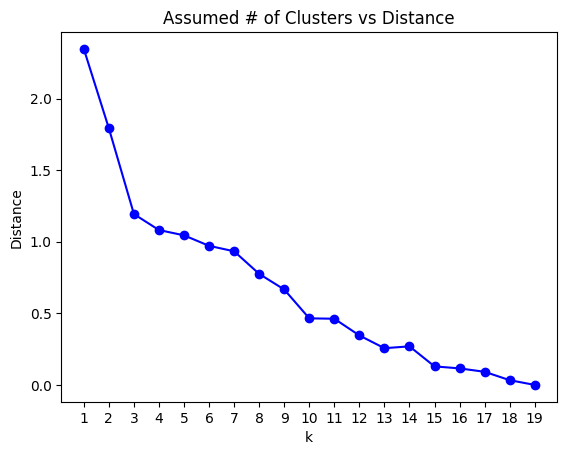

In [ ]:
data = [
    [0.14 , 0.14 , 0.28 , 0.44],
    [0.22 , 0.1 , 0.45 , 0.33],
    [0.1 , 0.19 , 0.25 , 0.4 ],
    [0.02 , 0.08 , 0.43 , 0.45],
    [0.16 , 0.08 , 0.35 , 0.3 ],
    [0.14 , 0.17 , 0.31 , 0.38],
    [0.05 , 0.14 , 0.35 , 0.5 ],
    [0.1 , 0.21 , 0.28 , 0.44],
    [0.04 , 0.08 , 0.35 , 0.47],
    [0.11 , 0.13 , 0.28 , 0.45],
    [0.0 , 0.07 , 0.34 , 0.65],
    [0.2 , 0.05 , 0.4 , 0.37],
    [0.12 , 0.15 , 0.33 , 0.45],
    [0.25 , 0.1 , 0.3 , 0.35],
    [0.0 , 0.1 , 0.4 , 0.5 ],
    [0.15 , 0.2 , 0.3 , 0.37],
    [0.0 , 0.13 , 0.4 , 0.49],
    [0.22 , 0.07 , 0.4 , 0.38],
    [0.2 , 0.18 , 0.3 , 0.4 ]
]

distances = []
k_vals = range(1, len(data)+1)

for k in k_vals:
    distances.append(k_means_distance(data,k))

import matplotlib.pyplot as plt

plt.plot(k_vals, distances, 'bo-')
plt.xlabel('k')
plt.ylabel('Distance')
plt.xticks(range(1, len(data)+1)) #makes sure integer x-axis variables
plt.title("Assumed # of Clusters vs Distance")
plt.show()